# LeetCode #1161: Maximum Level Sum of a Binary Tree

https://leetcode.com/problems/maximum-level-sum-of-a-binary-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **DFS with depth map** | $O(n)$ | $O(n)$ |
| **Optimal: BFS Level Order ★** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### DFS with depth map
DFS accumulates node values into a depth → sum map, then scans the map for the maximum. Correct, but requires a separate scan and a hash-map allocation.

### Optimal: BFS Level Order ★
BFS processes all nodes at each level in one batch, summing them directly. Track the running maximum and update the answer level whenever a new max sum is found.

**Why this is better than DFS:** No extra data structure — the queue naturally groups nodes by level and level number increments exactly once per BFS round.

**Constraints:**
* The number of nodes is in the range $[1, 10^4]$.
* $-10^5 \le$ Node.val $\le 10^5$
* Guaranteed to have at least one node with a positive sum level.

## Solutions

### C#

In [ ]:
public int MaxLevelSum(TreeNode root) {
    var queue = new Queue<TreeNode>();
    queue.Enqueue(root);
    int maxSum = int.MinValue, bestLevel = 1, level = 0;
    while (queue.Count > 0) {
        level++;
        int sz = queue.Count;
        long sum = 0;
        while (sz-- > 0) {
            var node = queue.Dequeue();
            sum += node.val;
            if (node.left  != null) queue.Enqueue(node.left);
            if (node.right != null) queue.Enqueue(node.right);
        }
        // Update best level when a strictly larger sum is found
        if (sum > maxSum) { maxSum = (int)sum; bestLevel = level; }
    }
    return bestLevel;
}

### Python

In [ ]:
from collections import deque

def maxLevelSum(self, root: Optional[TreeNode]) -> int:
    queue = deque([root])
    max_sum, best_level, level = float('-inf'), 1, 0
    while queue:
        level += 1
        level_sum = 0
        for _ in range(len(queue)):
            node = queue.popleft()
            level_sum += node.val
            if node.left:  queue.append(node.left)
            if node.right: queue.append(node.right)
        # Update best level when a strictly larger sum is found
        if level_sum > max_sum:
            max_sum = level_sum
            best_level = level
    return best_level

### Go

In [ ]:
import "math"

func maxLevelSum(root *TreeNode) int {
    queue := []*TreeNode{root}
    maxSum, bestLevel, level := math.MinInt32, 1, 0
    for len(queue) > 0 {
        level++
        sz, sum := len(queue), 0
        for i := 0; i < sz; i++ {
            node := queue[i]
            sum += node.Val
            if node.Left  != nil { queue = append(queue, node.Left) }
            if node.Right != nil { queue = append(queue, node.Right) }
        }
        queue = queue[sz:]
        // Update best level when a strictly larger sum is found
        if sum > maxSum { maxSum = sum; bestLevel = level }
    }
    return bestLevel
}

### Rust

In [ ]:
pub fn max_level_sum(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
    let mut queue = std::collections::VecDeque::new();
    if let Some(r) = root { queue.push_back(r); }
    let (mut max_sum, mut best_level, mut level) = (i64::MIN, 1i32, 0i32);
    while !queue.is_empty() {
        level += 1;
        let mut sum = 0i64;
        for _ in 0..queue.len() {
            let node = queue.pop_front().unwrap();
            let (val, l, r) = { let b = node.borrow(); (b.val as i64, b.left.clone(), b.right.clone()) };
            sum += val;
            if let Some(l) = l { queue.push_back(l); }
            if let Some(r) = r { queue.push_back(r); }
        }
        // Update best level when a strictly larger sum is found
        if sum > max_sum { max_sum = sum; best_level = level; }
    }
    best_level
}

## Example Scenarios

**1. Common Case**
**Input:** root = [1,7,0,7,-8,null,null]
Level 1 sum=1. Level 2 sum=7+0=7. Level 3 sum=7+(-8)=-1. Max=7 at level **2**.

**2. Slightly Complex**
**Input:** root = [989,null,10250,98693,-89388,null,null,null,-32127]
Level 1: 989. Level 2: 10250. Level 3: 98693+(-89388)=9305. Level 4: -32127. Max=10250 at level **2** — single large child beats a balanced level.

**3. Edge Case: Time Factor**
**Input:** A balanced tree with $10^4$ nodes, all values $= -10^5$
Every level sum is negative; the best level is 1 (root alone, least negative). BFS processes all $10^4$ nodes — $O(n)$ time. Each level sum is strictly negative but the algorithm correctly finds the maximum among them.

**4. Edge Case: Space Factor**
**Input:** A complete tree with $n = 10^4$ nodes; values alternate $\pm 10^5$
Last level has $\approx n/2$ nodes all enqueued simultaneously. Sum at last level could cancel to $\approx 0$. Queue peaks at $O(n/2) = O(n)$ space.

**5. Almost-Impossible but Plausible**
**Input:** Two levels where both sums are $2^{31} - 1$ (max int)
Using `int` for sum risks overflow; use `long` / `i64`. Problem says return the **smallest** level index when tie: the first level encountered with max sum wins because the update is strictly `>`, not `>=`.

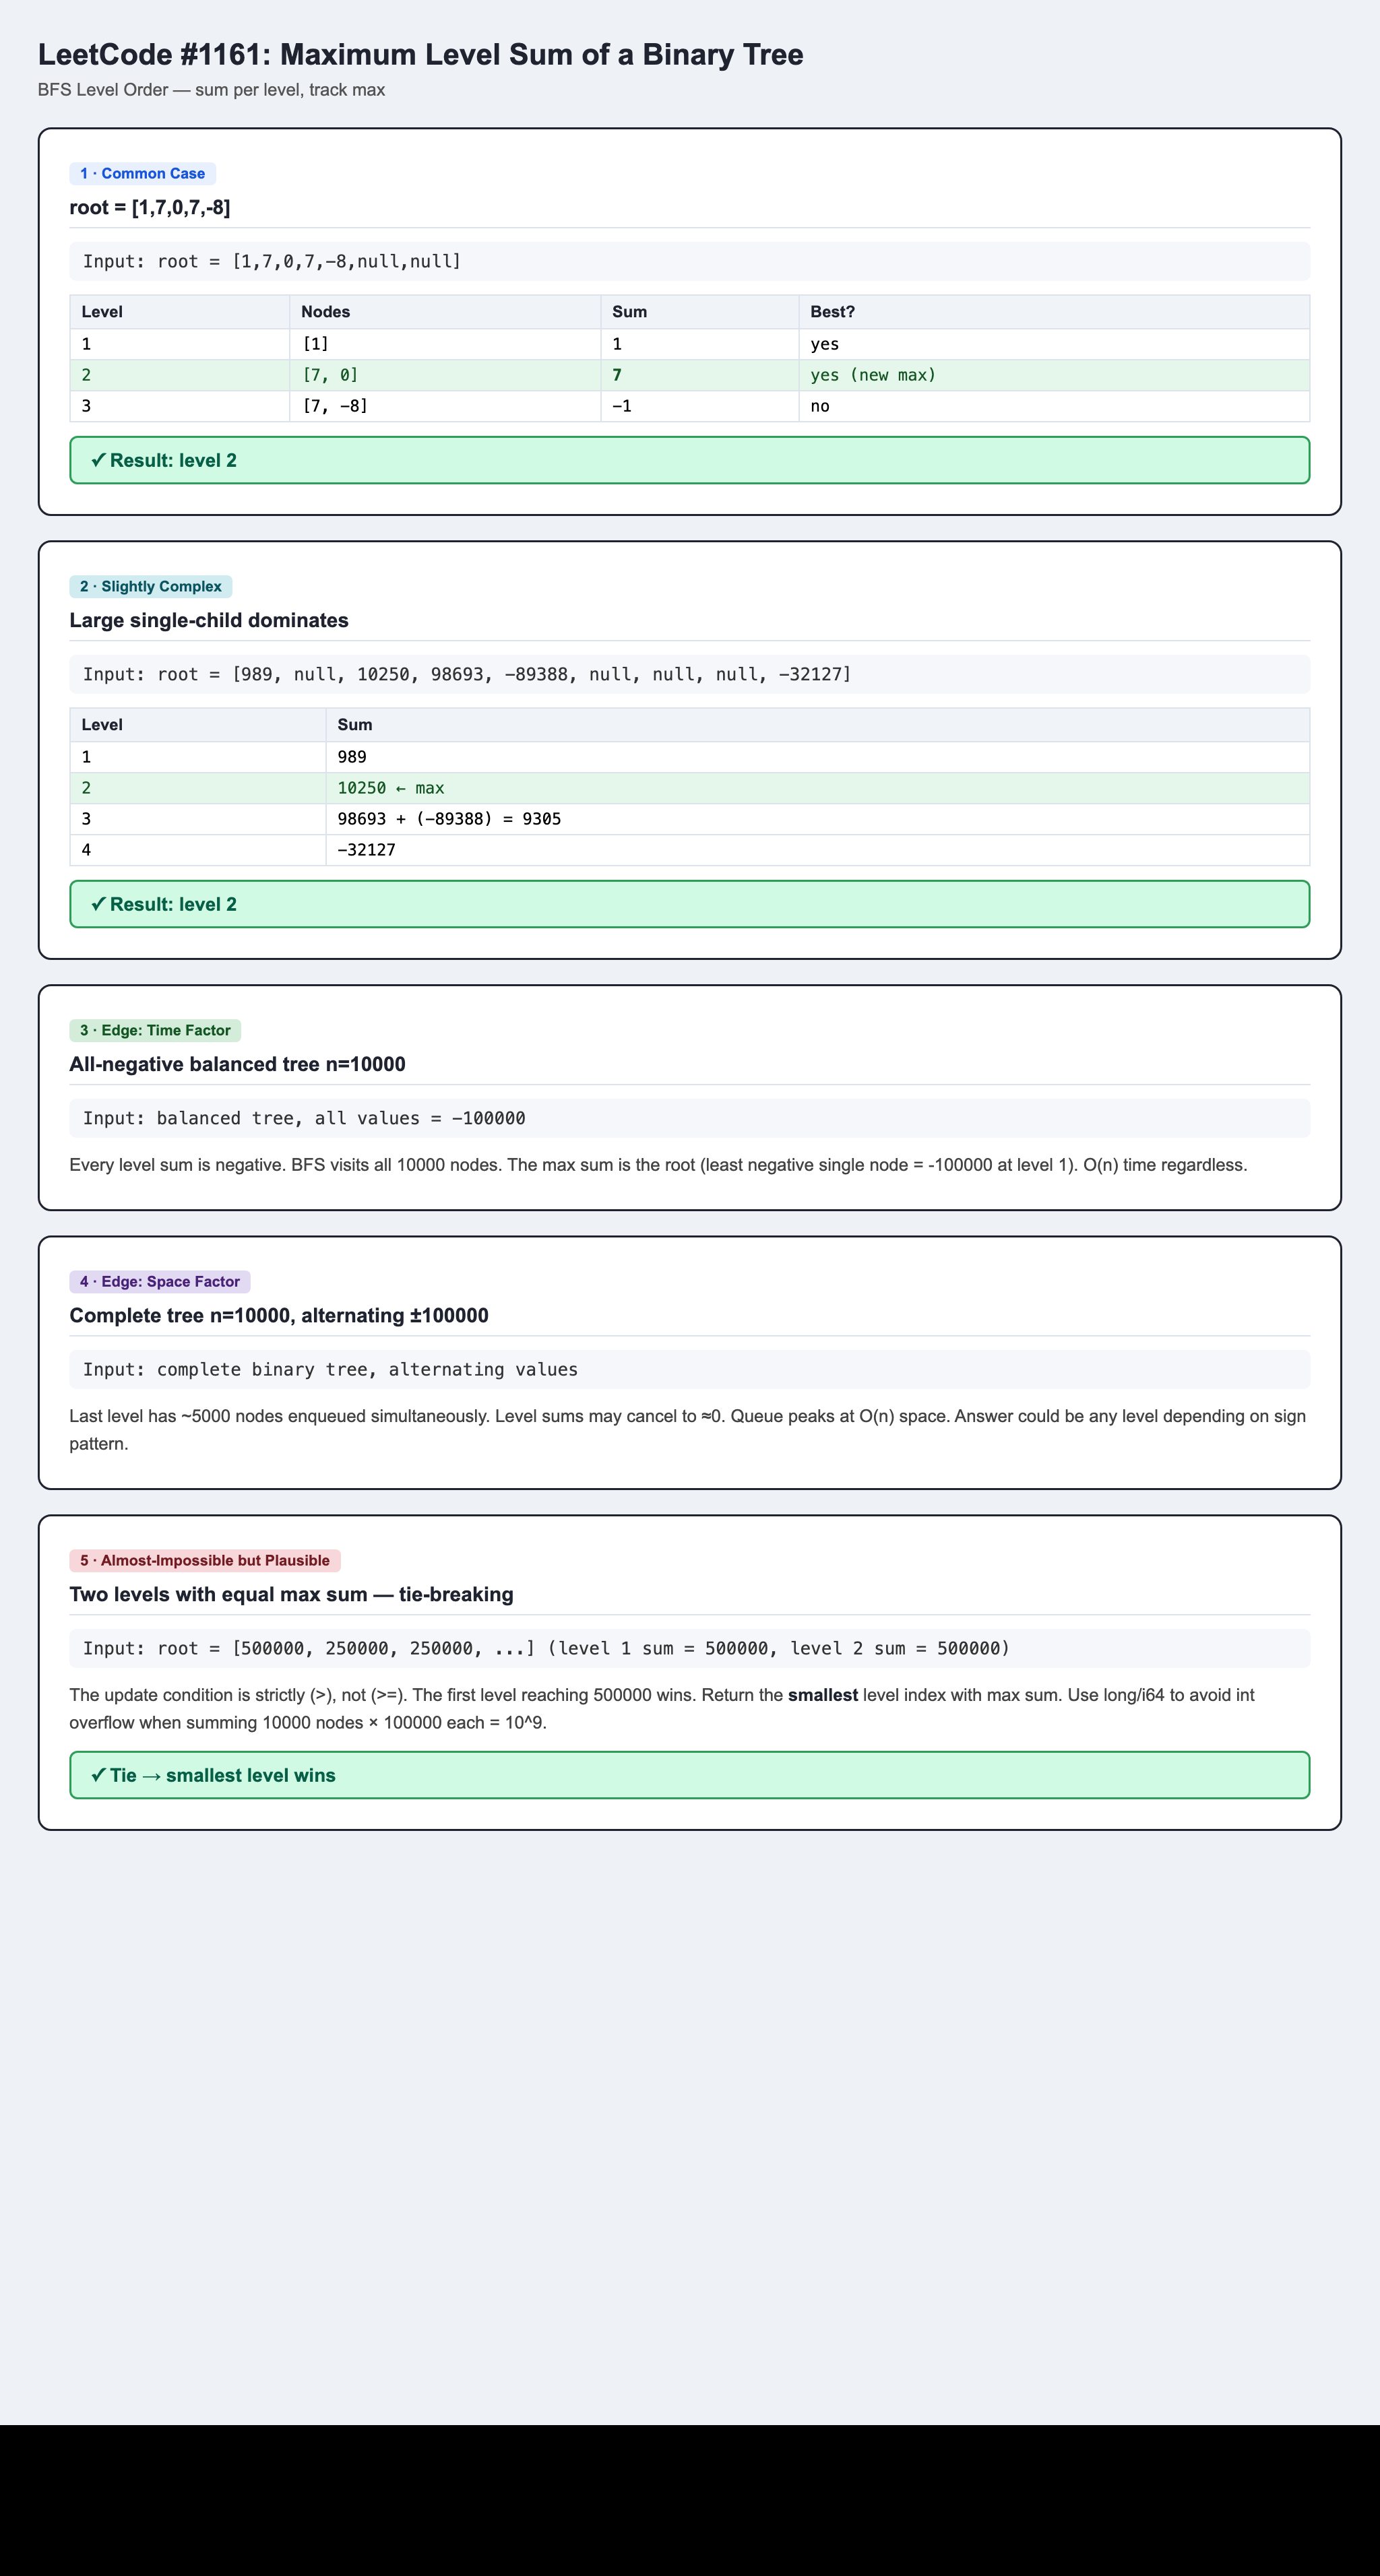